# This notebook uses data generated from generate_data.ipynb.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
from pathlib import Path
from src.fdm import pde_crank_nicolson_v3, pde_crank_nicolson_v7, build_grid
from src.options import EuropeanOption

In [2]:
def get_grid_spacings(K, S0, r, T, sigma, s_steps, t_steps):
    x, dx, tau, dt, _ = build_grid(K, S0, r, T, sigma, s_steps, t_steps, n_std=5)
    return dx, dt


In [3]:
file_path = "./data/test_run.parquet"
data = pd.read_parquet(file_path)
df=data.copy()
df = df[df.method=="cn_european"] # only using cn data
K, T, S0, r, sigma = df[['K', 'T', 'S0','r', 'sigma']].iloc[0] # these params were fixed for the sweep
df['s_steps'] = df['s_steps'].astype(int)
df['t_steps'] = df['t_steps'].astype(int)
df[['dx', 'dt']] = df.apply(
    lambda r: get_grid_spacings(r['K'], r['S0'], r['r'], r['T'], r['sigma'], r['s_steps'], r['t_steps']),
    axis=1, result_type='expand'
)

In [4]:
df = df[df.method == "cn_european"].sort_values(['version', 't_steps', 's_steps']) # only want european data
call = EuropeanOption(K=K, T=T, contract_type="call")
analytic = call.price_closed_form(S0, r, sigma)
df['bias'] = df['result'] - analytic
df['abs_bias'] = df['bias'].abs()
df.head(1)

,K,T,contract_type,S0,r,sigma,s_steps,t_steps,version,rep,...,time_ms,started,n,seed,steps,generator,dx,dt,bias,abs_bias
1992,100,1.0,call,100,0.05,0.2,32,32,v1,0,...,0.5864,2026-09-18 11:28:41.196926,NaN,NaN,NaN,NaN,0.071719,0.03125,-0.118878,0.118878


In [5]:
# First a quick sanity check: for eu options, cn methods v1, v2, and v3 should produce identical results. v4, v5, v6, v7 should also produce identical results

wide = df.groupby(['version', 's_steps', 't_steps'])['result'].mean().unstack('version')
versions = df.version.unique()
D = pd.DataFrame([[ (wide[a] - wide[b]).abs().max() for b in versions]
              for a in versions], index=versions, columns=versions)

TOL = 1e-10
print("green => the two versions produce same result. v4-v7 should be identical up to floating point error")
green = "#1b7f3b"
red = "#b3261e"
display(D.style.format('{:.2e}').map(lambda v: f'background-color: {green}; color: white' if v <= TOL else f'background-color: {red}; color: white'))

green => the two versions produce same result. v4-v7 should be identical up to floating point error


,v1,v2,v3,v4,v5,v6,v7
v1,0.00e+00,0.00e+00,2.42e-11,5.82e-02,5.82e-02,5.82e-02,5.82e-02
v2,0.00e+00,0.00e+00,2.42e-11,5.82e-02,5.82e-02,5.82e-02,5.82e-02
v3,2.42e-11,2.42e-11,0.00e+00,5.82e-02,5.82e-02,5.82e-02,5.82e-02
v4,5.82e-02,5.82e-02,5.82e-02,0.00e+00,4.79e-11,4.79e-11,4.80e-11
v5,5.82e-02,5.82e-02,5.82e-02,4.79e-11,0.00e+00,0.00e+00,9.97e-12
v6,5.82e-02,5.82e-02,5.82e-02,4.79e-11,0.00e+00,0.00e+00,9.97e-12
v7,5.82e-02,5.82e-02,5.82e-02,4.80e-11,9.97e-12,9.97e-12,0.00e+00


# Plot comparison of different versions (outputs nothing if only one version was used when generating data).

Comparing the impact of iterative optimisation changes to the time taken.
(error bars if data was generated using many repetitions to show potential cpu/resource jitter.)

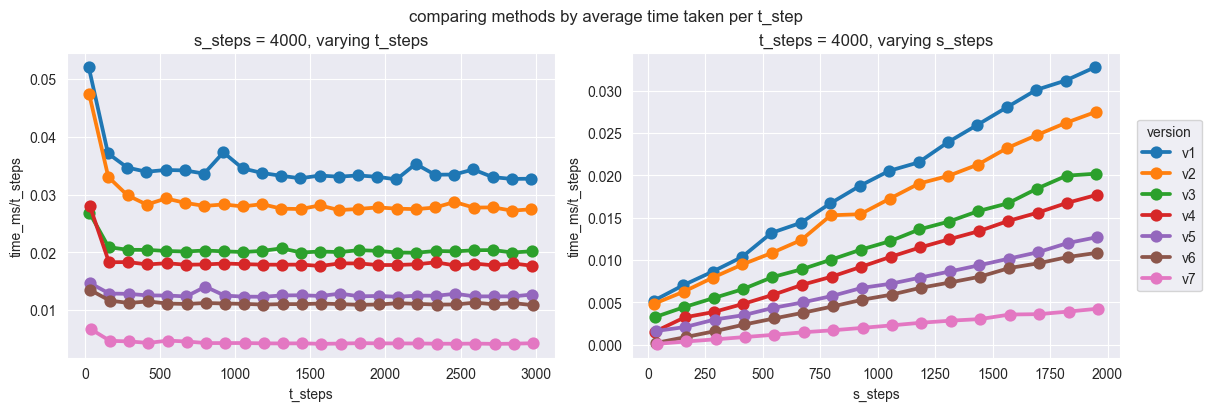

In [18]:
df['time_ms/t_steps'] = df['time_ms']/df['t_steps']
if df.version.nunique(dropna=True) == 1:
    pass
else:

    max_s_steps = df.s_steps.max()
    max_t_steps = df.t_steps.max()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)


    sns.pointplot(data=df[df.s_steps == max_s_steps], x='t_steps', y='time_ms/t_steps',
                  hue='version', errorbar='sd', capsize=.3, dodge=.1, native_scale=True, ax=axes[0])
    axes[0].set_title('s_steps = 4000, varying t_steps')

    sns.pointplot(data=df[df.t_steps == max_t_steps], x='s_steps', y='time_ms/t_steps',
                  hue='version', errorbar='sd', capsize=.3, dodge=.1, native_scale=True, ax=axes[1])
    axes[1].set_title('t_steps = 4000, varying s_steps')

    axes[0].get_legend().remove()

    fig.suptitle('comparing methods by average time taken per t_step')



    sns.move_legend(axes[1], loc='center left', bbox_to_anchor=(1.02, 0.5))

    Path("/figures").mkdir(parents=True, exist_ok=True)
    fig.savefig("figures/comparing_cn_implementations", dpi=300, bbox_inches="tight")



# show how cost vs accuracy scales (requires v7 to be in the dataset)

- Error is A * O(ds^2) + B * O(dt^2)
- Complexity for v7 is O(dt * ds)

fix t_steps, vary s_steps, and vice versa

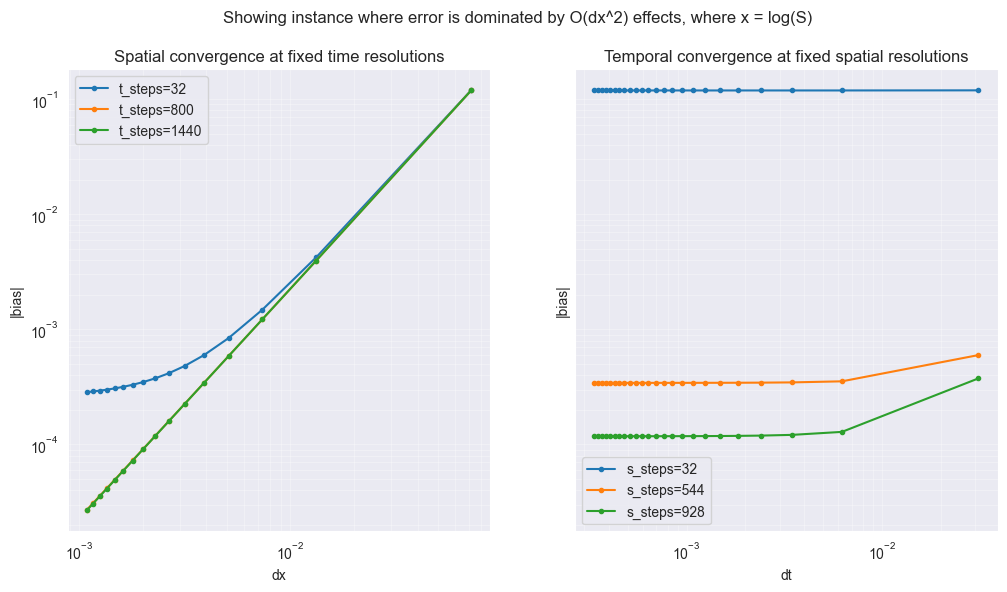

In [15]:
# Spatial convergence curves for several t_steps

version = "v7"
fig, ax = plt.subplots(figsize=(12, 6), nrows=1, ncols=2, sharey=True)
t_values = np.sort(df["t_steps"].unique())
s_values = np.sort(df["s_steps"].unique())
t_step_vals = np.sort(df["t_steps"].unique())
s_step_vals = np.sort(df["s_steps"].unique())

# pick a few values of t_steps and s_steps
#idx = np.linspace(0, len(t_values) - 1, min(16, len(t_values))).astype(int)
idx = [0,int(len(t_values)/4), int((len(t_values)-1)/2)]
for t_steps in t_values[idx]:
    d = df[(df.t_steps == t_steps) & (df.version == version)].sort_values("dx")

    ax[0].loglog(
        d["dx"],
        d["abs_bias"],
        marker="o",
        markersize=3,
        label=f"t_steps={t_steps}"
    )

    ax[0].set_xlabel("dx")
    ax[0].set_ylabel("|bias|")
    ax[0].set_title("Spatial convergence at fixed time resolutions")
    ax[0].grid(True, which="both", alpha=0.3)
    ax[0].legend()


idx = [0,int(len(s_values)/4), int((len(s_values)-1)/2)]
for s_steps in s_values[idx]:
    d = df[(df.s_steps == s_steps) & (df.version == version)].sort_values("dt")

    ax[1].loglog(
        d["dt"],
        d["abs_bias"],
        marker="o",
        markersize=3,
        label=f"s_steps={s_steps}"
    )

    ax[1].set_xlabel("dt")
    ax[1].set_ylabel("|bias|")
    ax[1].set_title("Temporal convergence at fixed spatial resolutions")
    ax[1].grid(True, which="both", alpha=0.3)
    ax[1].legend()

plt.suptitle("Showing instance where error is dominated by O(dx^2) effects, where x = log(S)")
plt.show()


Path("/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("figures/accuracy_vs_cost.png", dpi=300, bbox_inches="tight")

# Determine optimal s_steps and t_steps ratio

Previous cell shows that when s_steps $\approx$ t_steps, error due to s_steps dominates thus increased t_steps is pointless.

But can determine optimal ratio s_steps/t_steps as follows:

Let $N_s, N_t$ be number of s_steps, t_steps respectively.

The truncation error denoted by $\epsilon$ is $$ \epsilon(s, t) = A \cdot N_s^{-p} + B \cdot N_t^{-p} + \cdots$$

Holding $N_s$ fixed can define the error for fixed s_steps
$\epsilon_s(t)$. Can write $$ \epsilon_{s}(t) = \text{const} +  B \cdot (1/N_t)^p + \dots$$

And taking the difference $$\Delta_s(t_2, t_1) = \epsilon_{s}(t_2) - \epsilon_{s}(t_1) = B \cdot (1/N_{t_2})^p  - B \cdot (1/N_{t_1})^p + \dots $$
Rearranging $$B = \text{Constant} \approx  \frac{\Delta_s(t_2, t_1)}{N_{t_2}^{-p}  - N_{t_1}^{-p}}$$

To determine B accurately, should use $N_s$ large to isolate the effect of B and get a clean estimate. We assume to know $p = 2$ since that is the CN truncation error for the BS pde. Oscillations can be induced at boundary but v7 uses rannacher smoothing (last cell looks at oscillations).

Similarly, can find A by fixing t_steps instead.
##


In [16]:
p = 2

# fixing s_steps to 16000
last_error = None
last_nt = None
B = None
rows_t = []


for nt in (100, 250, 500, 1000, 2000, 4000):
    V, g = pde_crank_nicolson_v7(100., 100., .05, 1., .2, s_steps=16000, t_steps=nt)
    price = np.interp(np.log(100.), np.log(g['S']), V)
    error = price - analytic
    if last_error is None:
        last_error, last_nt = error, nt
    else:
        B = (error - last_error) / (1/nt**p - 1/last_nt**p)
        last_error, last_nt = error, nt
    rows_t.append({'t_steps': nt, 'error': error, 'B': B})

df_t = pd.DataFrame(rows_t).set_index('t_steps')
print("B should be constant")
display(df_t)

# fixing t_steps to 16000
last_error = None
last_ns = None
A = None
rows_s = []
for ns in (100, 250, 500, 1000, 2000, 4000):
    V, g = pde_crank_nicolson_v7(100., 100., .05, 1., .2, s_steps=ns, t_steps=16000)
    price = np.interp(np.log(100.), np.log(g['S']), V)
    error = price - analytic
    if last_error is None:
        last_error, last_ns = error, ns
    else:
        A = (error - last_error) / (1/ns**p - 1/last_ns**p)
        last_error, last_ns = error, ns
    rows_s.append({'s_steps': ns, 'error': error, 'A': A})

df_s = pd.DataFrame(rows_s).set_index('s_steps')
print("A should be constant")
display(df_s)


B = df_t.B.loc[250:2000].median()
A = df_s.A.loc[500:4000].median()
print(f"A={A:.4f}  B={B:.5f}  ratio={np.sqrt(A/B):.2f}")

B should be constant


,error,B
t_steps,,
100,-2.765727e-05,NaN
250,-4.796377e-06,-0.272153
500,-1.501184e-06,-0.274599
1000,-6.746657e-07,-0.275506
2000,-4.680796e-07,-0.275448
4000,-4.151443e-07,-0.282322


A should be constant


,error,A
s_steps,,
100,-0.010168,NaN
250,-0.001624,-101.716254
500,-0.000406,-101.498875
1000,-0.000101,-101.465157
2000,-0.000025,-101.456740
4000,-0.000006,-101.455762


A=-101.4609  B=-0.27502  ratio=19.21


# Oscillations near K for European Options priced with CN with/without smoothing

In [17]:
# in data saved we only keep the result (price at chosen S0), will redo to get a window around strike for each method (and for each
K = 100
T_STEPS = [500,501,1000, 1001]
WIN = 10

rows = []

fns = [pde_crank_nicolson_v3, pde_crank_nicolson_v7]
for fn in fns:
    for t_steps in T_STEPS:
        V, grid = fn(K, S0, r, T, sigma, s_steps=9000, t_steps=t_steps)
        S = grid['S']
        i = np.searchsorted(S, K)
        sl = slice(max(i - WIN, 0), i + WIN)
        rows.append(pd.DataFrame({
            'S': S[sl],
            'result': V[sl],
            'method': fn.__name__,
            't_steps': str(t_steps),   # string -> discrete colors
        }))

check_oscillations = pd.concat(rows, ignore_index=True)
check_oscillations['d2V'] = check_oscillations.groupby(['method', 't_steps'])['result'].transform(
    lambda s: s.diff().diff())

fig = px.line(check_oscillations, x='S', y='d2V', color='t_steps',
        facet_col='method', facet_col_wrap=3, markers=True, height=700,
        title='Second difference of V oscillation shows as sign flipping. v7 has Rannacher smoothing, v3 does not.')
fig.show()

Path("/figures").mkdir(parents=True, exist_ok=True)
fig.write_image("figures/effect_of_rannacher_smoothing.png", scale=2, width=1100, height=650)
check_oscillations

,S,result,method,t_steps,d2V
0,99.764544,10.301161,pde_crank_nicolson_v3,500,NaN
1,99.788065,10.316049,pde_crank_nicolson_v3,500,NaN
2,99.811591,10.330950,pde_crank_nicolson_v3,500,0.000014
3,99.835123,10.345857,pde_crank_nicolson_v3,500,0.000004
4,99.858660,10.360752,pde_crank_nicolson_v3,500,-0.000011
...,...,...,...,...,...
155,100.117936,10.525818,pde_crank_nicolson_v7,1001,0.000014
156,100.141540,10.540907,pde_crank_nicolson_v7,1001,0.000014
157,100.165150,10.556010,pde_crank_nicolson_v7,1001,0.000014
158,100.188765,10.571127,pde_crank_nicolson_v7,1001,0.000014
